# IPL 2022 Capstone Project

The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

These are some of the important columns that we'll focus on for meaningful insights in this project.

Column names: Variable Type
* date : string
* venue : string
* stage : string
* team1 : string
* team2 : string
* toss_winner : string
* toss_decision : string
* first_ings_score : integer
* second_ings_score : integer
* match_winner : string
* won_by : string
* margin : integer
* player_of_the_match : string
* top_scorer : string
* highscore : integer
* best_bowling : string
* best_bowling_fgure : string
* gure : string

# Loading the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import warnings
# warnings.filterwarnings('ignore')

# Loading the Dataset

In [2]:
try:
    df = pd.read_csv('IPL.csv')
except Exception as e:
    print(e)
else:
    print("Imported!")

Imported!


# Basic Information

In [3]:
print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")

Rows: 74
Columns: 20


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [5]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


In [6]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [7]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='str')

### Let's Check whether the dataset contains any null values

In [8]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

# Basic Questions

### 1. Which team won the most matches?

In [9]:
winners = df['match_winner'].value_counts()
winners

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0.5, 0, 'Matches Win')

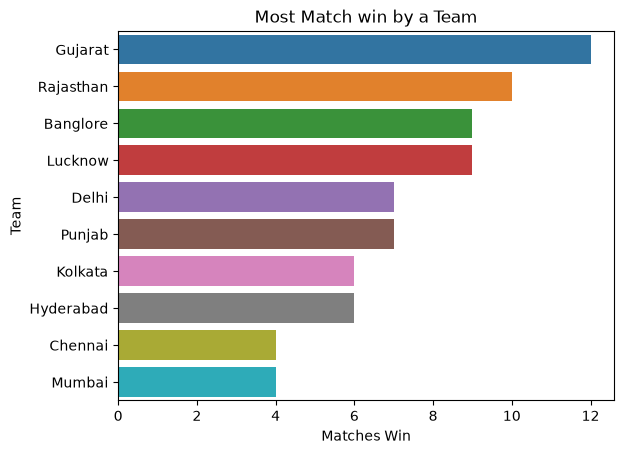

In [10]:
sns.barplot(x=winners.values, y=winners.index, hue=winners.index)
plt.title('Most Match win by a Team')
plt.ylabel('Team')
plt.xlabel('Matches Win')

### 2. Toss Decision Trends

Toss Decisions based on categories only

In [11]:
df['toss_decision'].value_counts()

toss_decision
Field    59
Bat      15
Name: count, dtype: int64

<Axes: xlabel='toss_decision', ylabel='count'>

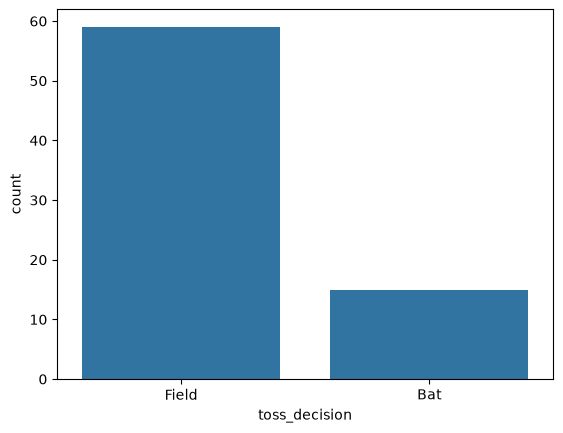

In [12]:
sns.countplot(x = df['toss_decision'])

Toss Decisions based on Team and their choices

In [13]:
df.groupby('toss_winner')['toss_decision'].value_counts()

toss_winner  toss_decision
Banglore     Field            6
             Bat              2
Chennai      Field            4
             Bat              2
Delhi        Field            8
Gujarat      Field            6
             Bat              4
Hyderabad    Field            9
             Bat              1
Kolkata      Field            7
             Bat              1
Lucknow      Field            5
             Bat              2
Mumbai       Field            9
Punjab       Field            3
             Bat              1
Rajasthan    Field            2
             Bat              2
Name: count, dtype: int64

<Axes: xlabel='toss_decision', ylabel='count'>

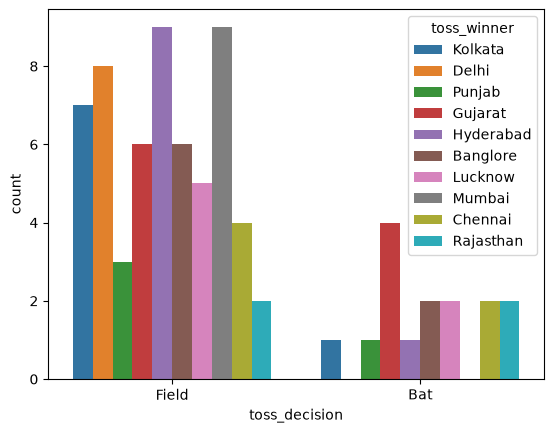

In [14]:
sns.countplot(x = df['toss_decision'], hue=df['toss_winner'])

### 3. Toss Winner vs Match Winner

In [15]:
count_both_winner = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
count_both_winner

np.int64(36)

Calculating the Percentage of both toss winner and match winner

In [16]:
percentage = (count_both_winner * 100)/df.shape[0]
print(f"Percentage of winning match if the team wins the toss: {percentage.round(2)}%")

Percentage of winning match if the team wins the toss: 48.65%


### 4. How do teams win? (Runs or Wickets)

In [17]:
df['won_by'].value_counts()

won_by
Wickets    37
Runs       37
Name: count, dtype: int64

Text(0.5, 1.0, 'Matches won by Wickets or Runs')

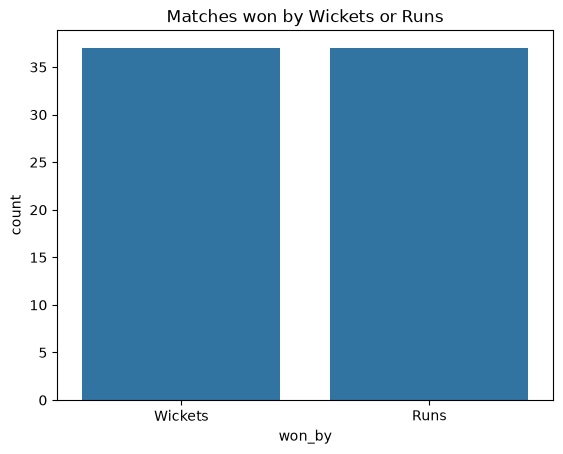

In [18]:
sns.countplot(x=df['won_by'])
plt.title('Matches won by Wickets or Runs')

In [19]:
df.groupby('won_by')['match_winner'].value_counts()

won_by   match_winner
Runs     Rajasthan       7
         Lucknow         7
         Banglore        5
         Gujarat         4
         Punjab          4
         Delhi           3
         Chennai         3
         Kolkata         2
         Mumbai          1
         Hyderabad       1
Wickets  Gujarat         8
         Hyderabad       5
         Kolkata         4
         Delhi           4
         Banglore        4
         Punjab          3
         Mumbai          3
         Rajasthan       3
         Lucknow         2
         Chennai         1
Name: count, dtype: int64

Text(0.5, 1.0, 'Matches Won by Wickets or Run based on Match Winner')

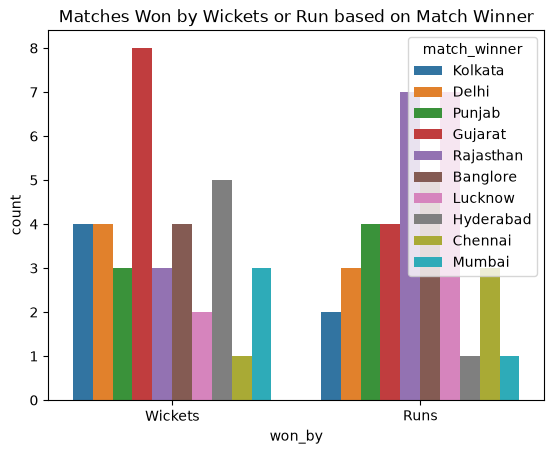

In [20]:
sns.countplot(data=df, x='won_by', hue='match_winner')
plt.title('Matches Won by Wickets or Run based on Match Winner')

# Key Player Performance

### 1. Most 'Player of the Match' Awards

In [21]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [22]:
count_potm = df['player_of_the_match'].value_counts()
count_potm

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Rahul Tripathi       2
K L Rahul            2
Umran Malik          2
David Miller         2
Jasprit Bumrah       2
Odean Smith          1
Mohammed Shami       1
Sanju Samson         1
Evin Lewis           1
Lockie Ferguson      1
Liam Livingstone     1
Pat Cummins          1
Abhishek Sharma      1
Anuj Rawat           1
Kane Williamson      1
Shivam Dube          1
Mayank Agarwal       1
Faf du Plessis       1
Mukesh Choudhary     1
Rashid Khan          1
Marco Jansen         1
Shikhar Dhawan       1
Riyan Parag          1
Krunal Pandya        1
Rahul Tewatia        1
Suruakumar Yadav     1
Mohsin Khan          1
Ruturaj Gaikwad      1
Rinku Singh          1
Kagiso Rabada        1
Harshal Patel        1
David Warner         1
Tim David     

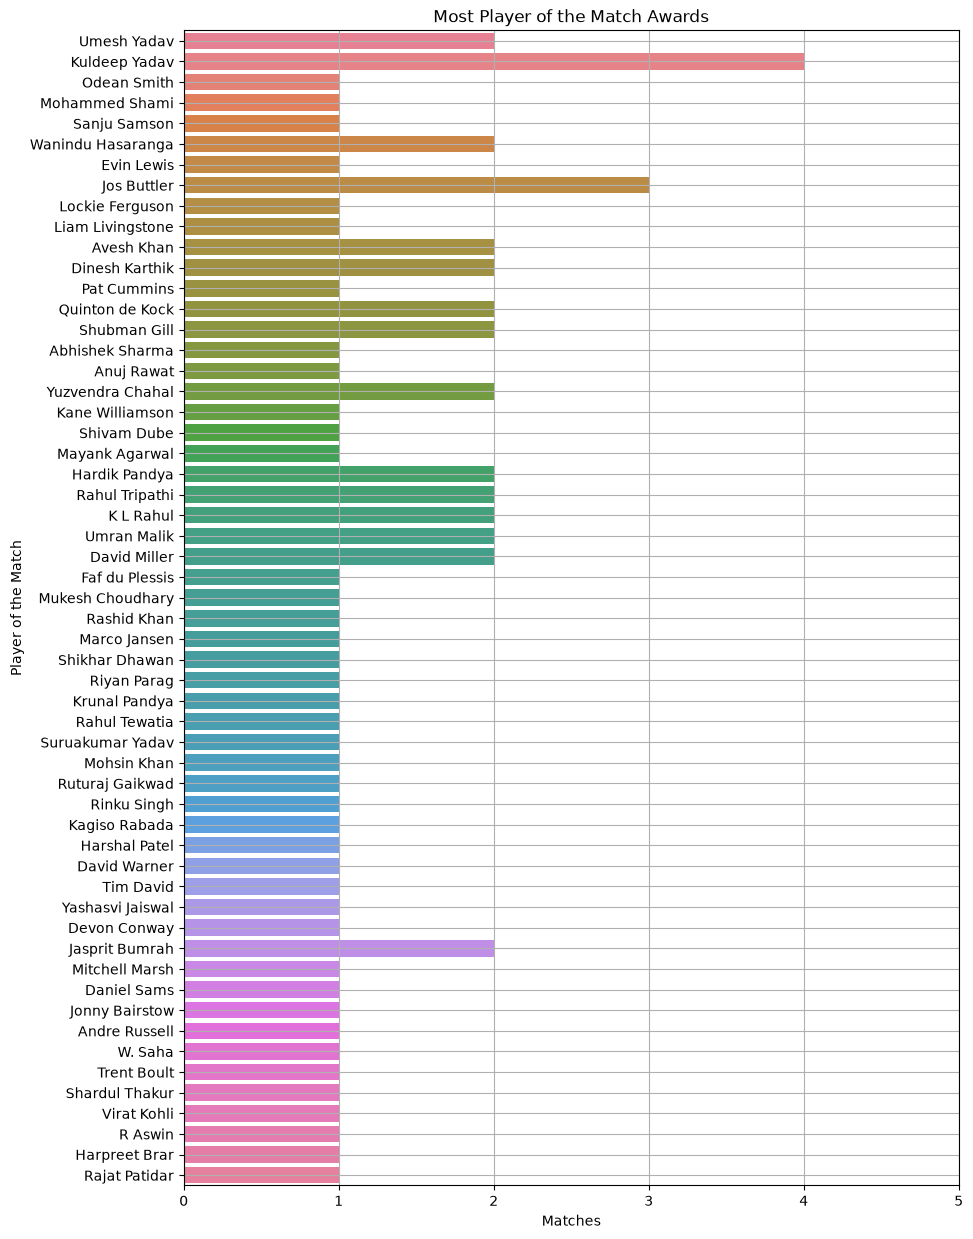

In [23]:
plt.figure(figsize=(10, 15))
sns.countplot(data=df, y='player_of_the_match', hue=df['player_of_the_match'])
plt.xticks(np.arange(0,6,1))
plt.ylabel('Player of the Match')
plt.xlabel('Matches')
plt.title('Most Player of the Match Awards')
plt.grid()
plt.show()

### 2. Top Scorers

In [24]:
count_top_scorers = df['top_scorer'].value_counts()
count_top_scorers

top_scorer
Jos Buttler            7
Quinton de Kock        5
Shubman Gill           4
Liam Livingstone       4
KL Rahul               4
Ishan Kishan           3
Faf du Plessis         3
David Warner           3
W. Saha                3
MS Dhoni               2
Deepak Hooda           2
Andre Russell          2
Abhishek Sharma        2
Shikhar Dhawan         2
Hardik Pandya          2
Rahul Tripathi         2
Virat Kohli            2
Devon Conway           2
Mitchell Marsh         2
Aiden Markram          1
Sherfane Rutherford    1
Pat Cummins            1
Suryakumar Yadav       1
Shimron Hetmyer        1
Kane Williamson        1
Shivam Dube            1
Dinesh Karthik         1
David Miller           1
Tilak Varma            1
Riyan Parag            1
Nitish Rana            1
Ruturaj Gaikwad        1
Sanju Samson           1
Sai Sudharsan          1
Yashasvi Jaiswal       1
Moeen Ali              1
Rajat Patidar          1
Name: count, dtype: int64

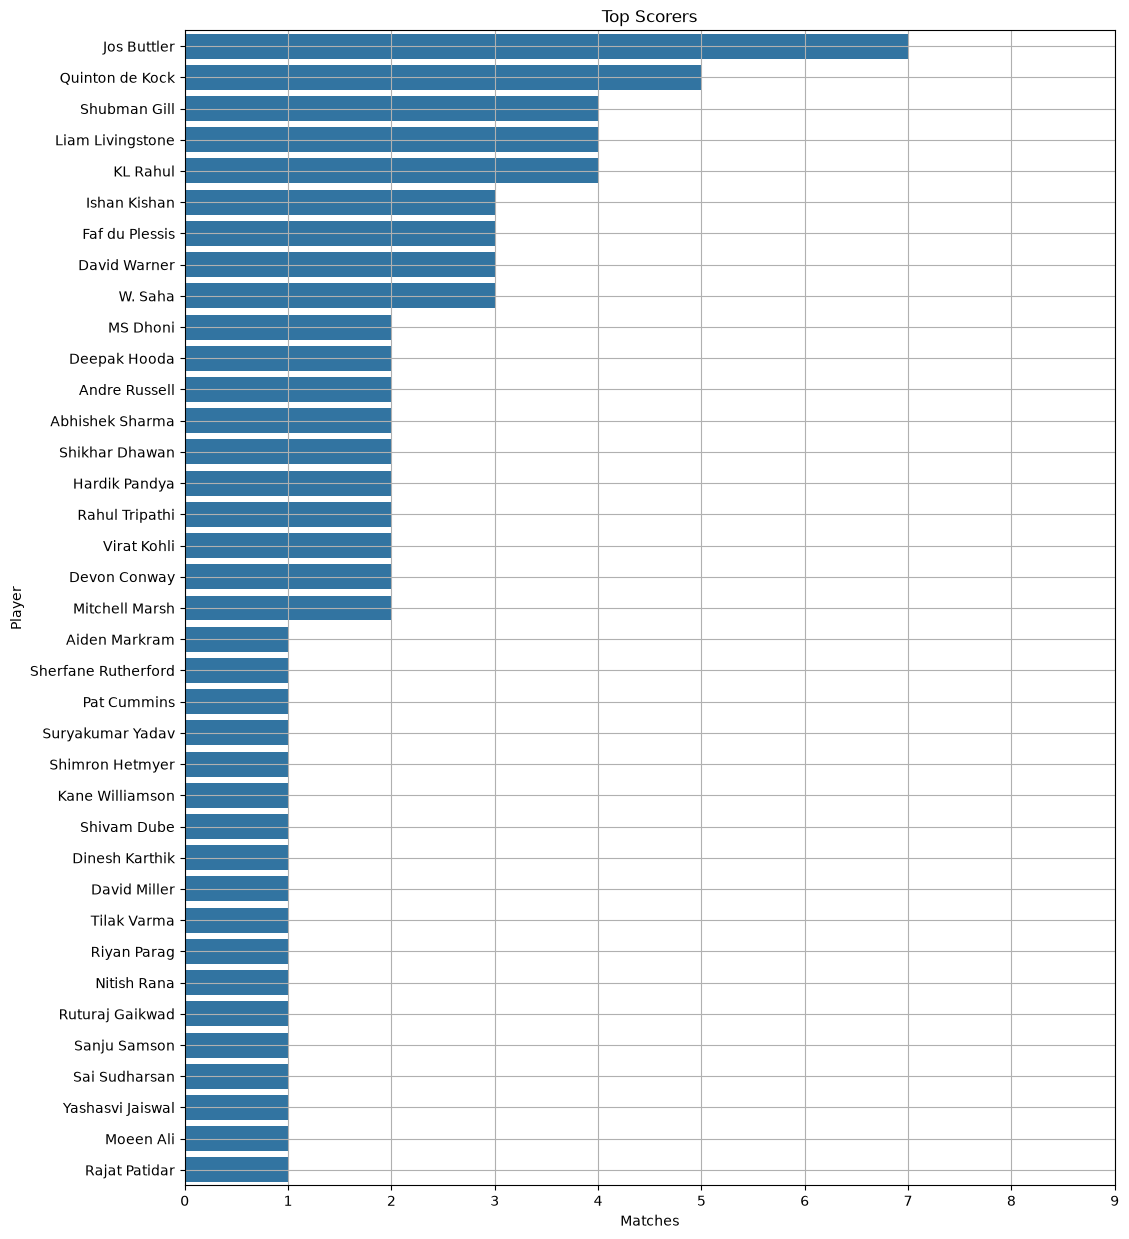

In [25]:
plt.figure(figsize=(12, 15))
sns.countplot(data=df, y='top_scorer', order=df['top_scorer'].value_counts().index)
plt.xticks(np.arange(0,10,1))
plt.title('Top Scorers')
plt.ylabel('Player')
plt.xlabel('Matches')
plt.grid()
plt.show()

In [26]:
scorer = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False)
scorer

top_scorer
Jos Buttler            651
Quinton de Kock        377
KL Rahul               351
Shubman Gill           288
Faf du Plessis         257
Liam Livingstone       239
David Warner           213
W. Saha                190
Ishan Kishan           180
Shikhar Dhawan         158
Hardik Pandya          154
Mitchell Marsh         152
Rahul Tripathi         147
Devon Conway           143
Virat Kohli            131
Abhishek Sharma        122
Andre Russell          119
Deepak Hooda           114
Rajat Patidar          112
Ruturaj Gaikwad         99
Shivam Dube             95
David Miller            94
Moeen Ali               93
MS Dhoni                86
Yashasvi Jaiswal        68
Suryakumar Yadav        68
Dinesh Karthik          66
Sai Sudharsan           65
Shimron Hetmyer         59
Aiden Markram           57
Kane Williamson         57
Nitish Rana             57
Pat Cummins             56
Riyan Parag             56
Sanju Samson            54
Tilak Varma             51
Sherfane Rutherfo

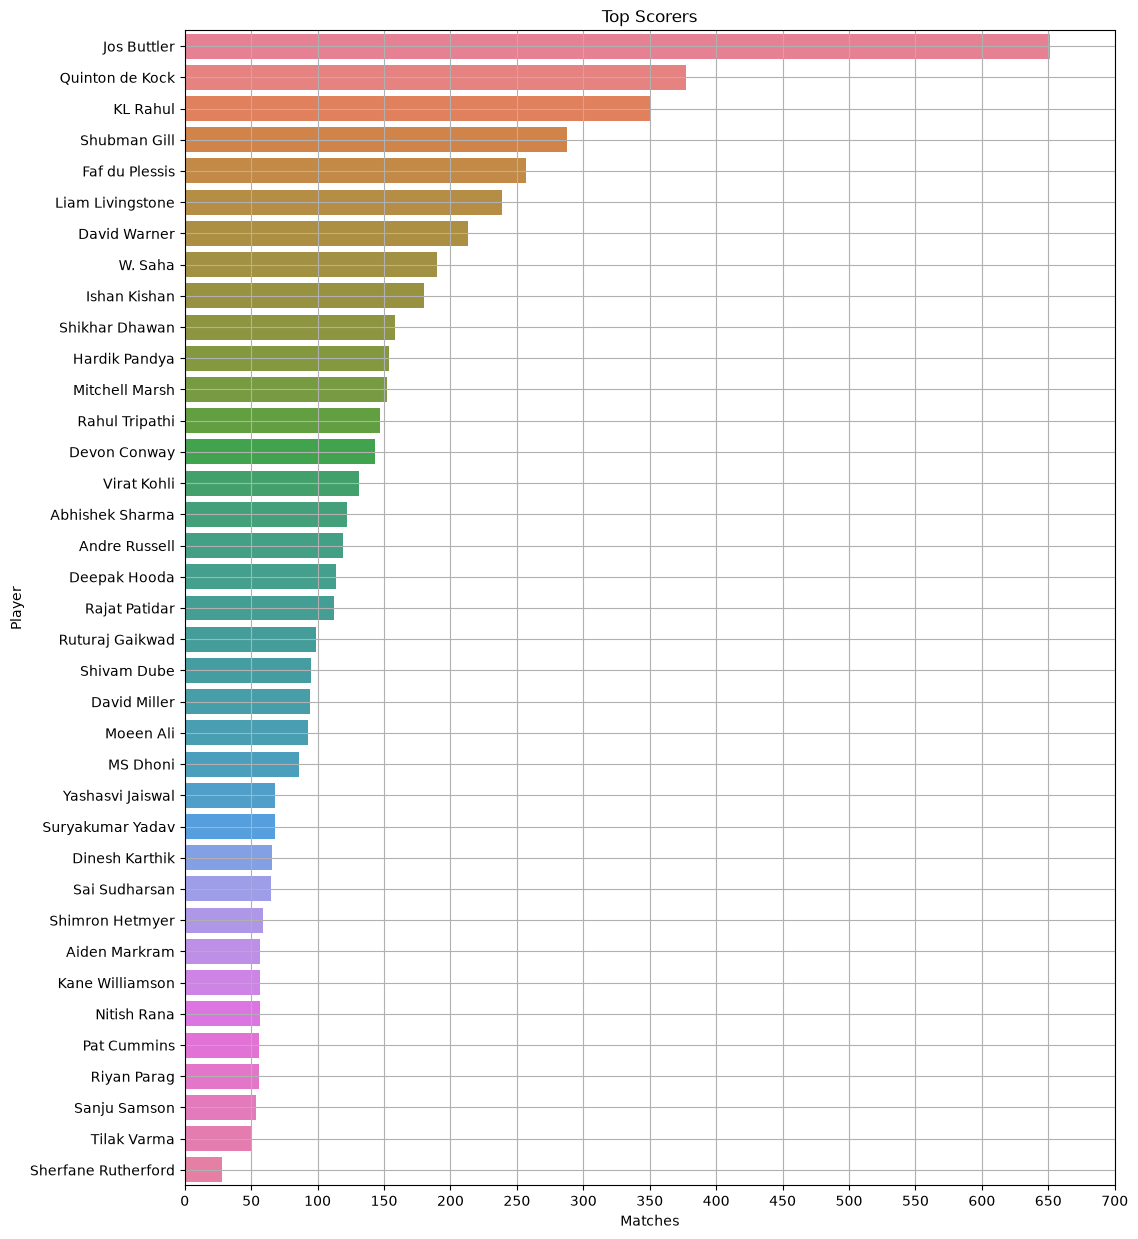

In [27]:
plt.figure(figsize=(12, 15))
sns.barplot(y=scorer.index, x=scorer.values, hue=scorer.index)
plt.xticks(np.arange(0,750,50))
plt.title('Top Scorers')
plt.ylabel('Player')
plt.xlabel('Matches')
plt.grid()
plt.show()

### 3. Find the top 2 scorers

In [28]:
scorer.head(2)

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

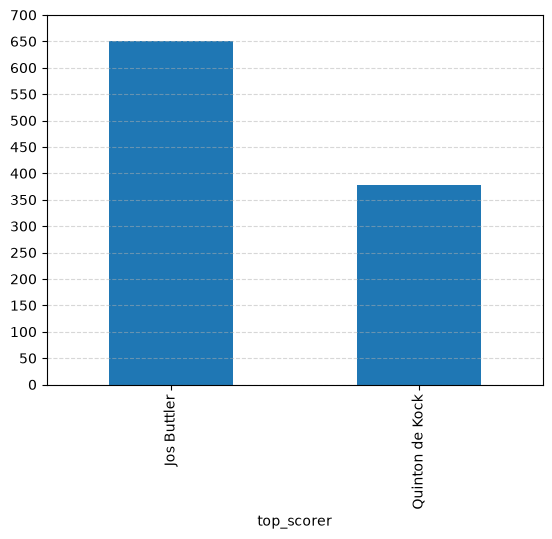

In [29]:
scorer.head(2).plot(kind='bar')
plt.yticks(np.arange(0,750, 50))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 4. 10 Best Bowling Figures 

In [30]:
count_best_bowler = df['best_bowling'].value_counts().head(10)
count_best_bowler

best_bowling
Yuzvendra Chahal    5
Rashid Khan         4
Kuldeep Yadav       3
Jasprit Bumrah      3
Avesh Khan          3
T Natarajan         3
Josh Hazlewood      3
Kagiso Rabada       3
Dwayne Bravo        2
Mohammed Shami      2
Name: count, dtype: int64

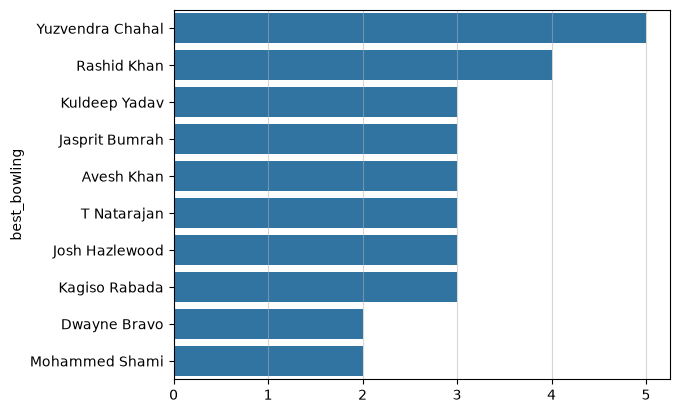

In [31]:
sns.barplot(x=count_best_bowler.values, y=count_best_bowler.index)
plt.grid(axis='x', alpha=0.5)

In [32]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x : x.split('--')[0]).astype(int)
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,...,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26,3
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,...,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14,1
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,...,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43,3
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,...,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22,3


In [33]:
count_highest_wickets = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False)
count_highest_wickets

best_bowling
Yuzvendra Chahal      17
Jasprit Bumrah        11
Kuldeep Yadav         11
Rashid Khan           11
Josh Hazlewood        10
Kagiso Rabada         10
Avesh Khan            10
Umran Malik            9
Wanindu Hasaranga      9
T Natarajan            8
Maheesh Theekshana     7
Mohsin Khan            7
Lockie Ferguson        7
Andre Russell          7
Daniel Sams            7
Harshal Patel          6
Dwayne Bravo           6
Prasidh Krishna        6
Mohammed Shami         5
Shardul Takur          4
Ravi Bishnoi           4
Hardik Pandya          4
Umesh Yadav            4
Mukesh Choudhary       4
Odean Smith            4
Kuldeep Sen            4
Krunal Pandya          3
Khaleel Ahmed          3
Harpreet Brar          3
Rahul Chahar           3
Ramandeep Singh        3
Moeen Ali              3
Chetan Sakariya        2
Axar Patel             2
Pradeep Sangwan        2
Murugan Ashwin         2
Mohammed Siraj         2
Prashant Solanki       2
Rilley Meredith        2
Tim Southee 

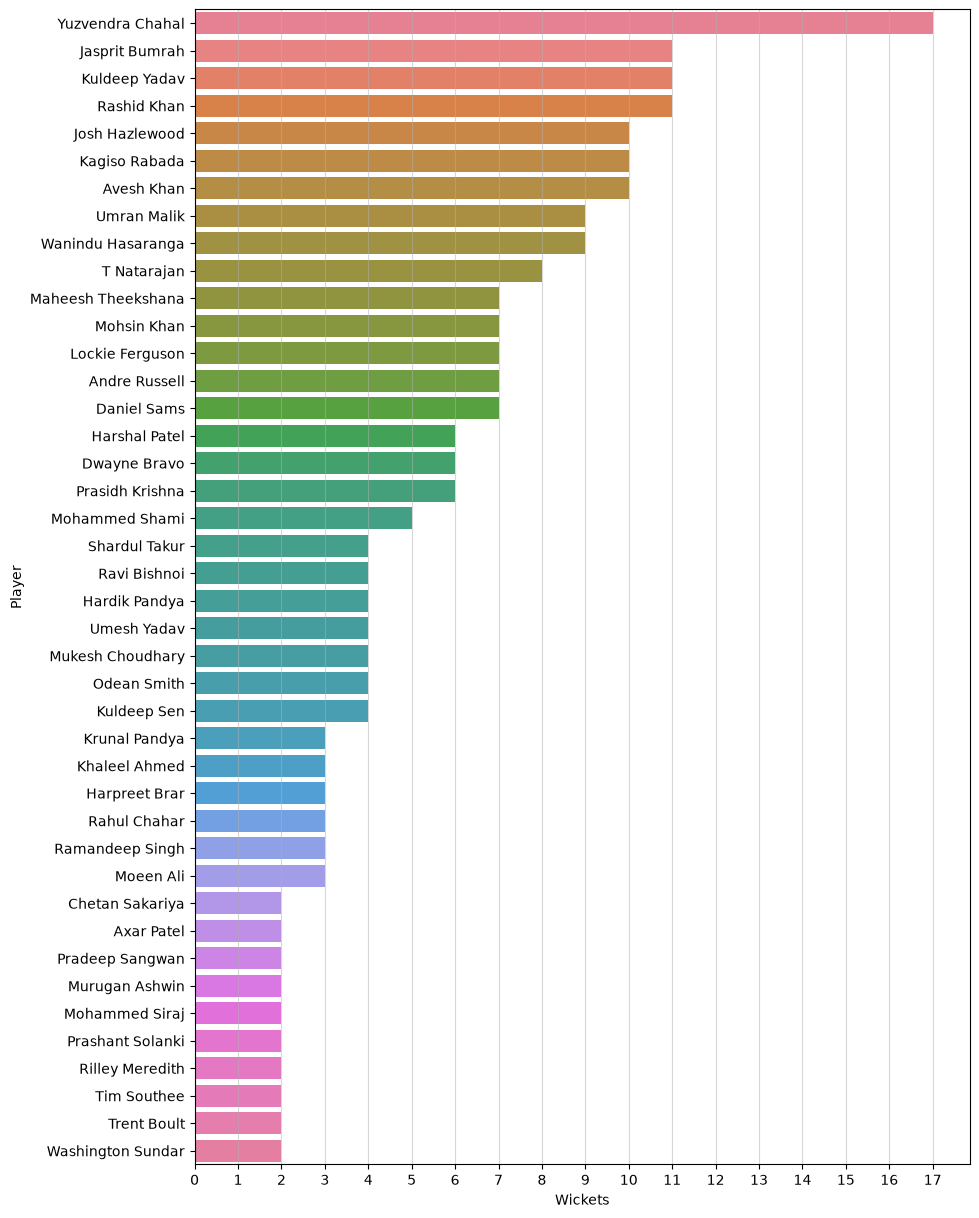

In [34]:
plt.figure(figsize=(10, 15))
sns.barplot(x=count_highest_wickets.values, y=count_highest_wickets.index, hue=count_highest_wickets.index)
plt.xticks(np.arange(0, 18, 1))
plt.xlabel('Wickets')
plt.ylabel('Player')
plt.grid(axis='x', alpha=0.5)
plt.show()

# Value Analysis

### 1. Most matches played by Venue

In [35]:
count_venue = df['venue'].value_counts()
count_venue

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

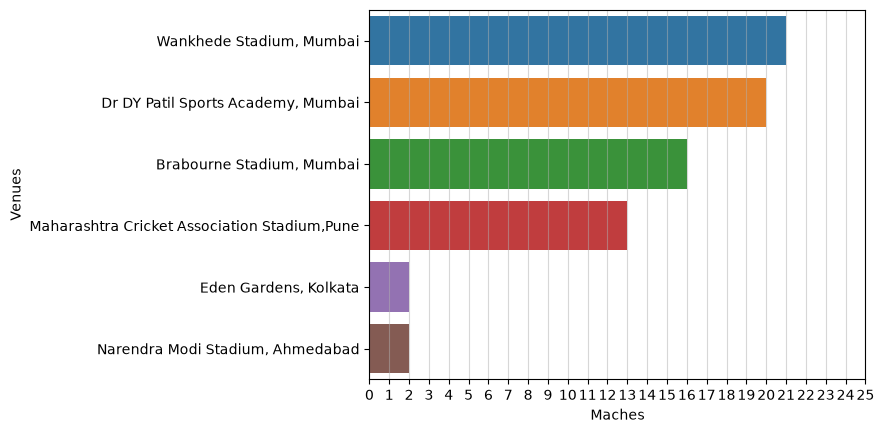

In [40]:
sns.barplot(x=count_venue.values, y=count_venue.index, hue=count_venue.index)
plt.xticks(np.arange(0, 26, 1))
plt.xlabel('Maches')
plt.ylabel('Venues')
plt.grid(axis='x', alpha=0.5)
plt.show()

# Custom Questions & Insights

### 1. Who won the highest margin by runs?

In [48]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


In [46]:
df['margin'].max()

np.int64(91)

In [63]:
highest_margin = df[df['won_by']=='Runs'].sort_values(by='margin', ascending=False).head(1)[['match_winner', 'margin']]
highest_margin

,match_winner,margin
54,Chennai,91


### 2. Which player has the highest individual score?

In [66]:
df.sort_values(by='highscore', ascending=False).head(1)[['top_scorer', 'highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


### 3. Which bowler had the best bowling figure?

In [70]:
df.sort_values(by='highest_wickets', ascending=False).head(1)[['best_bowling', 'highest_wickets']]

,best_bowling,highest_wickets
29,Yuzvendra Chahal,5
